# Resolución Trabajo Práctico 02

## Integrantes

- Gaspar Acevedo Zain

## Carga del dataset

### Imports y carga del dataset

In [539]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from category_encoders import TargetEncoder, HashingEncoder

In [540]:
df_procesado = pd.read_csv("../dataset/sneep-2023-procesamiento.csv")

In [541]:
# Configuramos el output display con 100 filas
pd.options.display.max_rows = 100
# Configuramos el output display con 100 columnas
pd.options.display.max_columns = 100

## Helper functions

In [542]:
# Devuelve datos relativos a columnas numéricas, tales como media, skewness, kurtosis, entre otros
def get_metrics_from_numeric_column(data, column):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    moda = (data[column]).mode()[0]
    mediana = (data[column]).median()
    var = (data[column]).var()
    std = (data[column]).std()
    min = (data[column]).min()
    max = (data[column]).max()

    return media, moda, mediana, min, max, var, std, skewness, kurtosis

In [543]:
# Devuelve métricas relacionadas al rango Intercuartil
def get_iqr_metrics(data, column):
    Q1 = data[column].quantile(0.25)
    Q2 = data[column].quantile(0.50)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1
    min_iqr = Q1 - 1.5*IQR
    max_iqr = Q3 + 1.5*IQR

    return Q1, Q2, Q3, IQR, min_iqr, max_iqr

In [544]:
# defino un color default
default_green_color = "#1F968BFF"

# Código provisto por la materia
# Función para graficar Histogramas, junto con skewness, kurtosis, media, varianza, y/o desvío estandar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False, color=default_green_color, xlabel=None):
    media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(data, column)

    x_label = xlabel if xlabel is not None else f'{column}'

    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde, color=color)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    plt.axvline(moda, color='purple', linestyle='--', label='Moda')
    plt.axvline(mediana, color='green', linestyle='--', label='Mediana')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Moda: {moda:.2f}', fontsize=10, color='purple')
        plt.figtext(0.15, 0.66, f'Mediana: {mediana:.2f}', fontsize=10, color='green')
        plt.figtext(0.15, 0.59, f'Var: {var:.2f}', fontsize=10, color='black')
        plt.figtext(0.15, 0.52, f'Std: {std:.2f}', fontsize=10, color='black')
    plt.title(f'Variable: {x_label}')
    plt.xlabel(f'{x_label}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [545]:
def graficar_comparacion_transformaciones(df_original, df_normalizado, df_estandarizado, 
                                          columns, titulos = ["Original", "Normalizado (MinMax)", "Estandarizado (Z-Score)"],
                                          figsize = (10,10), colores = ["gray", "blue", "red"]):
    fig, axes = plt.subplots(nrows=len(columns), ncols=3, figsize=figsize)

    for i, col in enumerate(columns):
        sns.histplot(df_original[col], kde=True, ax=axes[i, 0], color=colores[0])
        sns.histplot(df_normalizado[col], kde=True, ax=axes[i, 1], color=colores[1])
        sns.histplot(df_estandarizado[col], kde=True, ax=axes[i, 2], color=colores[2])

        axes[i, 0].set_ylabel(col)
        for j in range(3):
            axes[i, j].set_xlabel("")
            axes[i, j].set_title(titulos[j])
    plt.tight_layout()
    plt.show()

In [546]:
def graficar_comparacion_tratamiento_outliers(df_original, df_media, df_mediana, df_moda, df_log, df_sqrt,
                                          col, titulos = ["Original", "Transformación logaritmica", "Transformación por raíz cuadrada", "Imputación por media", "Imputación por mediana", "Imputación por moda"],
                                          figsize = (10,10), colores = ["gray", "blue", "red", "green", "purple", "black"]):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)

    sns.histplot(df_original[col], kde=True, ax=axes[0, 0], color=colores[0])
    sns.histplot(df_log[col], kde=True, ax=axes[0, 1], color=colores[1])
    sns.histplot(df_sqrt[col], kde=True, ax=axes[0, 2], color=colores[2])

    sns.histplot(df_media[col], kde=True, ax=axes[1, 0], color=colores[3])
    sns.histplot(df_mediana[col], kde=True, ax=axes[1, 1], color=colores[4])
    sns.histplot(df_moda[col], kde=True, ax=axes[1, 2], color=colores[5])

    axes[0, 0].set_ylabel(col)

    for i in range (2):
        for j in range(3):
            axes[i, j].set_xlabel("")
            axes[i, j].set_title(titulos[i*3+j])
    plt.tight_layout()
    plt.show()

## Paso 1 - Split del dataset

Antes de realizar operaciones tales como tratamiento de nulos, tratamiento de outliers, creación de nuevas features, entre otras, debemos separar el dataset en *train* y *test*.

### Paso 1.1 - Repaso de columnas

Comencemos repasando las columnas del dataset:

In [547]:
df_procesado.columns.tolist()

['provincia_descripcion',
 'establecimiento_descripcion',
 'edad',
 'genero_descripcion',
 'nacionalidad_descripcion',
 'estado_civil_descripcion',
 'nivel_instruccion_descripcion',
 'ultima_situacion_laboral_descripcion',
 'capacitacion_laboral_al_ingresar_descripcion',
 'ultimo_lugar_residencia_descripcion',
 'ultima_provincia_residencia_descripcion',
 'jurisdiccion_descripcion',
 'situacion_legal_descripcion',
 'establecimiento_procedencia_descripcion',
 'delito1_descripcion',
 'delito2_descripcion',
 'delito3_descripcion',
 'delito4_descripcion',
 'delito5_descripcion',
 'horas_trabajo_remunerado_descripcion',
 'participacion_programa_laboral',
 'participacion_programa_educativo_descripcion',
 'participacion_actividades_deportivas',
 'recibio_atencion_medica_ult_anio',
 'recibio_atencion_medica_ult_anio_descripcion',
 'recibio_visitas_ultimo_anio',
 'participo_alteracion_orden_ult_anio_descripcion',
 'tipo_infraccion_disciplinaria_descripcion',
 'sancion_aplicada_descripcion',
 'ca

In [548]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_laboral,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,2,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,1,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,1.0,0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como se pueder observar, quedaron las siguientes columnas correspondientes a `IDs`:

- `participacion_programa_laboral` (su descripción equivalente está en la columna `participacion_programa_educativo_descripcion`)
- `recibio_atencion_medica_ult_anio` (su descripción equivalente está en la columna `recibio_atencion_medica_ult_anio_descripcion`)

Se decide trabajar con las variables categóricas, por lo cual eliminamos aquellas que corresponden a `IDs`.

In [549]:
columnas_a_eliminar = [
    "participacion_programa_laboral",
    "recibio_atencion_medica_ult_anio"
]

In [550]:
df_procesado = df_procesado.drop(columns=columnas_a_eliminar)

In [551]:
df_procesado.columns.size

44

De esta manera, el dataset queda con *44 columnas*:

In [552]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,1.0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [553]:
df_procesado["tipo_condena"].unique()

array([ 0.,  1., nan])

El siguiente paso será dividir las columnas en distintos grupos, para tratarlas en pasos posteriores según corresponda:

Columnas *numéricas*:

- `edad`
- `duracion_condena_anios`
- `duracion_condena_meses`

Columnas *booleanas*:

- `participacion_actividades_deportivas`
- `recibio_visitas_ultimo_anio`
- `tentativa_suicidio`
- `participa_programa_pre_libertad`

*Otras* columnas:

- `tipo_condena`: presenta como valores únicos a `0`, `1`, y `nan`. No se tiene suficiente información para definirla como *booleana* o *categórica*.

Columna objetivo o *target*:

- `tuvo_reduccion_pena_descripcion`

El resto de las columnas son categóricas.

In [554]:
col_numericas = [
    "edad",
    "duracion_condena_anios",
    "duracion_condena_meses"
]

col_booleanas = [
    "participacion_actividades_deportivas",
    "recibio_visitas_ultimo_anio",
    "tentativa_suicidio",
    "participa_programa_pre_libertad"
]

col_otras = [
    "tipo_condena"
]

target = "tuvo_reduccion_pena_descripcion"

col_objetivo = [target]

In [555]:
col_categoricas = list(set(df_procesado.columns) - set(col_booleanas + col_otras + col_numericas + col_objetivo))

### Paso 1.2 - Split en Train y test

Con el fin de hacer el split de manera equilibrada entre clases (ver [stratify](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)), llenamos temporalmente los *nulos* con el string literal `nan`.
Luego, se imputarán según corresponda.

In [556]:
df_procesado[target] = df_procesado[target].fillna("nan")

In [557]:
# definimos un random_state
random_state = 649739
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(
    df_procesado.drop(columns=target),
    df_procesado[target],
    random_state=random_state,
    test_size=test_size,
    stratify=df_procesado[target])

## [REFACTORIZAR y llevar a Paso 7] Paso x - Normalización y estandarización

El siguiente paso corresponde a aplicar técnicas de normalización y estandarización a las siguientes variables numéricas:

- `edad`
- `duracion_condena_anios`
- `duracion_condena_meses`

### Paso 2.1 - Normalización

Aplicamos normalización a las variables numéricas mediante la clase [MixMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.transform).

In [ ]:
# scaler = MinMaxScaler()
# df_train_escalado = pd.DataFrame(scaler.fit_transform(X_train[col_numericas]), columns=col_numericas)
# df_test_escalado = pd.DataFrame(scaler.transform(X_test[col_numericas]), columns=col_numericas)

### Paso 2.2 - Estandarización

Estandarizamos a las variables numéricas mediante la clase [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.transform).

In [ ]:
# standard_scaler = StandardScaler()
# df_train_estandarizado = pd.DataFrame(standard_scaler.fit_transform(X_train[col_numericas]), columns=col_numericas)
# df_test_estandarizado = pd.DataFrame(standard_scaler.transform(X_test[col_numericas]), columns=col_numericas)

### Paso 2.3 - Comparación mediante gráficos

A continuación se grafica la distribución de las variables numéricas en los dataset de `train` *original*, *normalizado* y *estandarizado*.

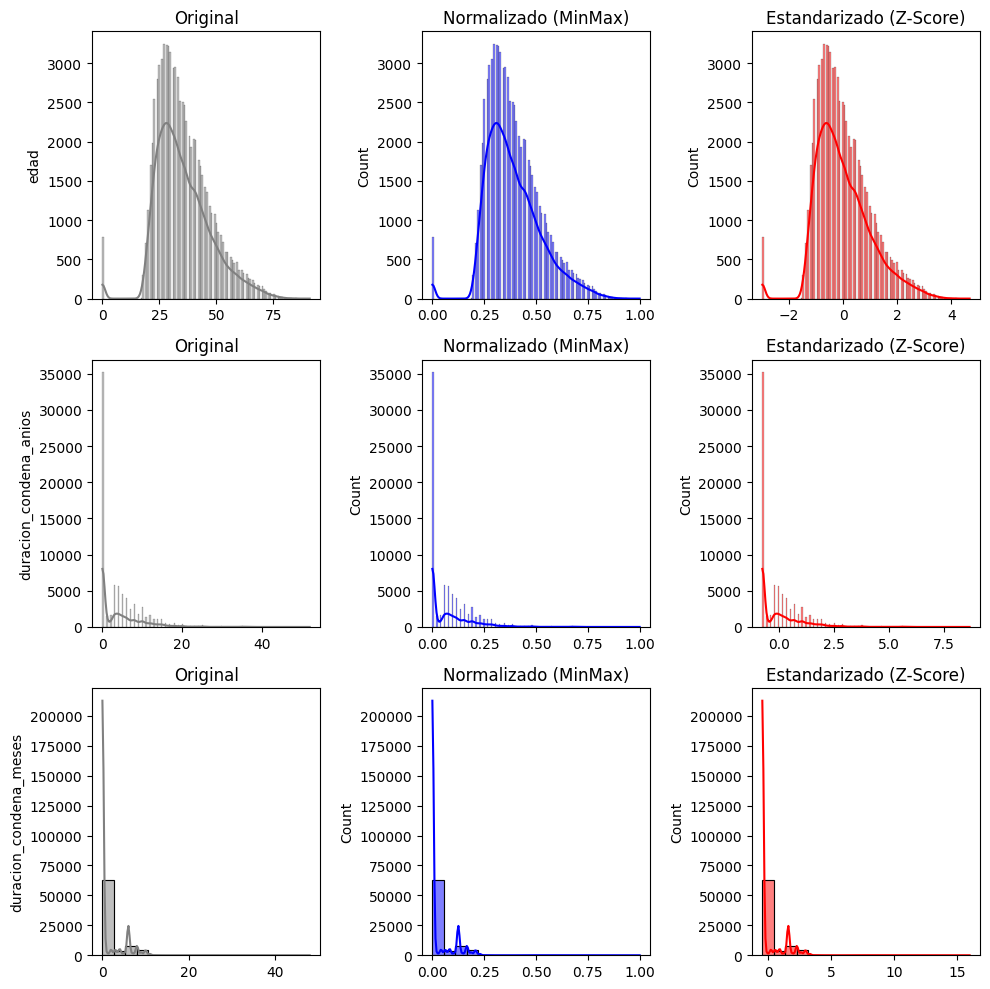

In [ ]:
# graficar_comparacion_transformaciones(df_original=X_train,
#                                       df_normalizado=df_train_escalado,
#                                       df_estandarizado=df_train_estandarizado,
#                                       columns=col_numericas)

A continuación se grafica la distribución de las variables numéricas en los dataset de `test` *original*, *normalizado* y *estandarizado*.

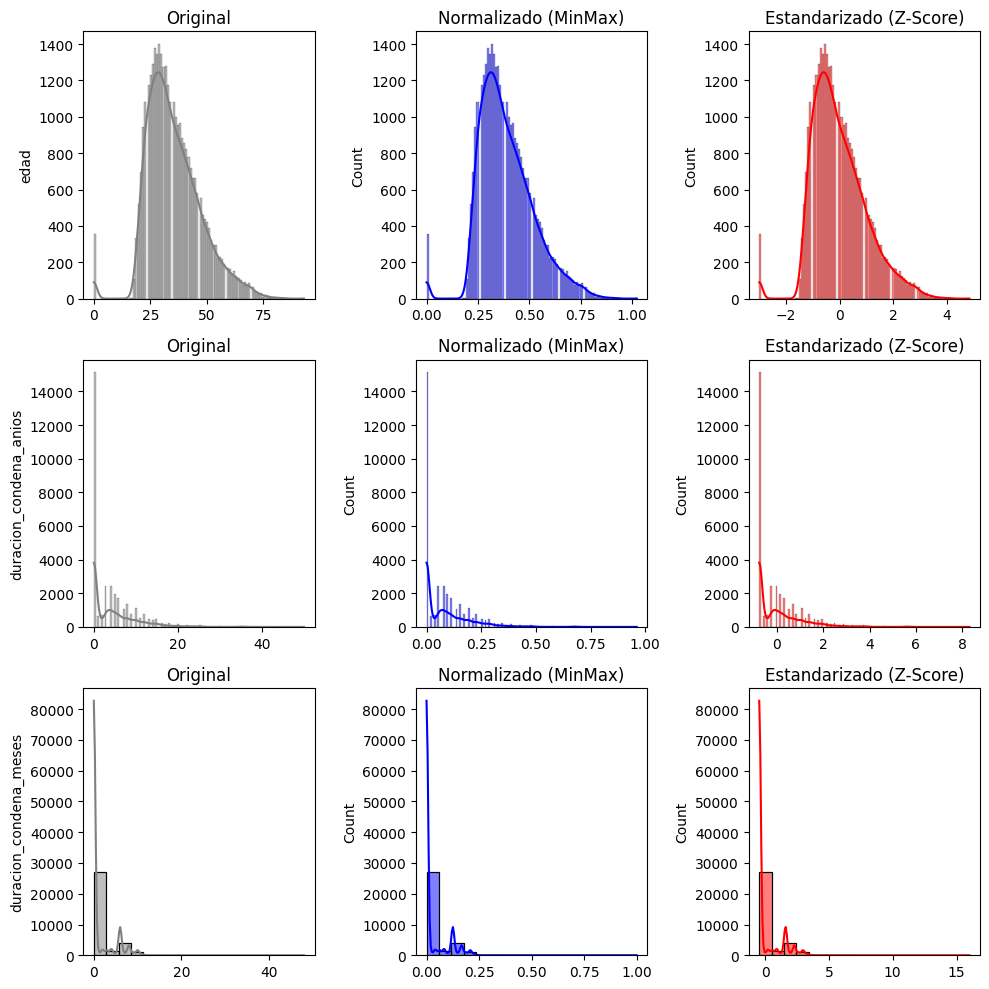

In [ ]:
# graficar_comparacion_transformaciones(df_original=X_test,
#                                       df_normalizado=df_test_escalado,
#                                       df_estandarizado=df_test_estandarizado,
#                                       columns=col_numericas)

Como se puede observar en los gráficos, las distribuciones se mantienen para todas las variables, tanto al estandarizar como al normalizar los datasets de *train* y *test*.

Se opta por utilizar la estandarización de estas variables, ya que esta puede resultar útil al trabajar con algoritmos tales como `Regresión Lineal` y `SVM`, mientras que la normalización resulta útil para algoritmos tales como `KNN`, el cual es poco probable que se utilice en casos como este.

Por este motivo, reemplazaremos las columnas numéricas el los datasets *train* y *test* por sus valores `estandarizados`.

Antes de aplicar estos cambios a la variables `edad`, hay que recordar que esta variable presentaba un total de `785` datos nulos (con edad igual a cero).

Por eso, se valida que la cantidad de registros con valor mínimo de `edad` estandarizada (`-2.994274675689943`) sea también de `785`, lo cual se demuestra en las siguientes celdas:

In [ ]:
# df_train_estandarizado["edad"].min()

-2.9925445288900447

In [ ]:
# len(df_train_estandarizado[df_train_estandarizado["edad"] == df_train_estandarizado["edad"].min()])

787

In [ ]:
# len(X_train[X_train["edad"]==0])

787

### Paso 2.4 - Reemplazo de variables numéricas *originales* por estandarizadas

Se reemplazan las columnas numéricas originales en los datasets *train* y *test* por sus valores `estandarizados`.

In [ ]:
# # El reset_index es necesario para actualizar correctamente los nuevos valores, sino genera nulos
# X_train = X_train.reset_index()
# X_test = X_test.reset_index()

# for col in col_numericas:
#     X_train[col] = df_train_estandarizado[col]
#     X_test[col] = df_test_estandarizado[col]

## Paso 2 - Tratamiento de nulos

### Paso 2.1 - Repaso de nulos en el dataset

A continuación se repasan las variables que tienen datos faltantes y su tipo, según lo analizado en el `Trabajo Práctico nro. 1`.

| Columna | Cantidad de datos faltantes | Tipo de causa de datos faltantes | Comentarios |
| --- | --- | --- | --- |
| provincia_descripcion                               |       0 | - | - |
| establecimiento_descripcion                         |    3012 | MCAR | - |
| genero_descripcion                                  |       0 | - | - |
| nacionalidad_descripcion                            |     721 | MCAR | - |
| estado_civil_descripcion                            |    2891 | MCAR | - |
| nivel_instruccion_descripcion                       |    7737 | MCAR | - |
| ultima_situacion_laboral_descripcion                |     889 | MCAR | - |
| capacitacion_laboral_al_ingresar_descripcion        |    4205 | MCAR | - |
| ultimo_lugar_residencia_descripcion                 |      65 | MCAR | - |
| ultima_provincia_residencia_descripcion             |     591 | MCAR | - |
| jurisdiccion_descripcion                            |      12 | MCAR | - |
| situacion_legal_descripcion                         |       0 | - | - |
| establecimiento_procedencia_descripcion             |    1900 | MCAR | - |
| delito1_descripcion                                 |     590 | MCAR | - |
| delito2_descripcion                                 |   87909 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito3_descripcion                                 |  105385 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito4_descripcion                                 |  110104 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito5_descripcion                                 |  111446 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| horas_trabajo_remunerado_descripcion                |     423 | MCAR | - |
| participacion_programa_educativo_descripcion        |    4179 | MCAR | - |
| participacion_actividades_deportivas                |    2227 | MCAR | - |
| recibio_atencion_medica_ult_anio_descripcion        |    4819 | MCAR | - |
| recibio_visitas_ultimo_anio                         |    2812 | MCAR | - |
| participo_alteracion_orden_ult_anio_descripcion     |    1838 | MCAR | - |
| tipo_infraccion_disciplinaria_descripcion           |    1589 | MCAR | - |
| sancion_aplicada_descripcion                        |   95702 | MCAR | - |
| calificacion_conducta_descripcion                   |    3737 | MCAR | - |
| tentativa_fugas_evasiones_descripcion               |     227 | MCAR | - |
| tentativa_suicidio                                  |       0 | - | - |
| fue_lesionado_descripcion                           |     665 | MCAR | - |
| tipo_condena                                        |   46325 | MAR | 96.31% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| es_reincidente_descripcion                          |   48931 | MAR | 91.18% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| tiene_periodo_progresividad_descripcion             |   47173 | MAR | 94.58% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| reparticion_descripcion                             |    3012 | MCAR | - |
| tuvo_salidas_transitorias_descripcion               |   48567 | MAR | 91.86% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| incorporado_reg_semi_libertad_descripcion           |   46364 | MAR | 96.23% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_pre_libertad                     |   47713 | MAR | 93.5% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_prision_discontinua_descripcion  |   48167 | MAR | 92.63% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_semi_detencion_descripcion       |   47465 | MAR | 94% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| tuvo_reduccion_pena_descripcion                     |   48275 | MAR | 92.41% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| mujer_tiene_hijos_intramuro                         |  107325 | MAR | 100% de faltantes se deben a valores distintos de `Mujer` de la variable `genero_descripcion` |
| edad                                                |  1145   | MCAR  | Edad con valor igual a *cero*. |

### Paso 2.2 - Imputación de `MAR`

De la tabla del `Paso 2.1` se destacan los siguientes casos correspondientes a `MAR`:

1. Los valores distintos a `Condenado/a` en la variable `situacion_legal_descripcion` generan la mayoría de los valores *nulos* en las siguientes variables:
    1. `tipo_condena`, `es_reincidente_descripcion`, `tiene_periodo_progresividad_descripcion`, `tuvo_salidas_transitorias_descripcion`, `incorporado_reg_semi_libertad_descripcion`, `participa_programa_pre_libertad`, `participa_programa_prision_discontinua_descripcion`, `participa_programa_semi_detencion_descripcion` y `tuvo_reduccion_pena_descripcion`
    1. Esto es razonable, ya que estas variables describen situaciones correspondientes a personas que tienen condena.
1. Los valores *nulos* en la variable `mujer_tiene_hijos_intramuros` se deben a que el género (`genero_descripcion`) es distinto de `Mujer`, lo cual es lógico.
1. Las variables `delito2_descripcion`, `delito3_descripcion`, `delito4_descripcion` y `delito5_descripcion` tienen la mayoría de sus valores nulos. Esto se debe a que el registro NO necesariamente puede tener más de un delito.

Para resolverlos, se realizará lo siguiente:

1. Variables afectadas por `situacion_legal_descripcion`.
    1. Si `situacion_legal_descripcion` es ***distinto*** a `Condenado/a`, se imputará a cada una de las variables afectadas con el valor `Sin condena`.
    1. Si `situacion_legal_descripcion` es ***igual*** a `Condenado/a`, se imputará a cada una de las variables afectadas con la `moda` de este subjconjunto.
1. Registros con valores nulos en `mujer_tiene_hijos_intramuros`
    1. Si `genero_descripcion` es ***distinto*** a `Mujer`, se imputará con el valor `No aplica`
    1. Si `genero_descripcion` es ***igual*** a `Mujer`, se imputará con la `moda` de este subconjunto.
1. Las variables `delito2_descripcion`, `delito3_descripcion`, `delito4_descripcion` y `delito5_descripcion` serán eliminadas, ya que la mayoría son valores nulos.
    1. Los porcentajes de nulos son $78.51%$, $94.12%$, $98.34%$ y $99.53%$ respectivamente.

#### Paso 2.2.1 - Imputación de variables afectadas por valores distintos a `Condenado/a` en `situacion_legal_descripcion`

Primero, tenemos que convertir las variables `tipo_condena` y `participa_programa_pre_libertad` en string, ya que son (a priori) *booleanas*, pero sus valores son *float64*.

In [558]:
cols_to_string = [
    "tipo_condena",
    "participa_programa_pre_libertad"
]

for col in cols_to_string:
    train_not_na_mask = X_train[col].notna()
    test_not_na_mask = X_test[col].notna()

    X_train.loc[train_not_na_mask, col] = X_train.loc[train_not_na_mask, col].astype(str)
    X_test.loc[test_not_na_mask, col] = X_test.loc[test_not_na_mask, col].astype(str)

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1400\864544693.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '1.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_train.loc[train_not_na_mask, col] = X_train.loc[train_not_na_mask, col].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1400\864544693.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '0.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_test.loc[test_not_na_mask, col] = X_test.loc[test_not_na_mask, col].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1400\864544693.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pan

In [559]:
const_condenado = "Condenado/a"
const_sin_condena = "Sin condena"
cols_afectadas_condenado = [
    "tipo_condena",
    "es_reincidente_descripcion",
    "tiene_periodo_progresividad_descripcion",
    "tuvo_salidas_transitorias_descripcion",
    "incorporado_reg_semi_libertad_descripcion",
    "participa_programa_pre_libertad",
    "participa_programa_prision_discontinua_descripcion",
    "participa_programa_semi_detencion_descripcion"
    #"tuvo_reduccion_pena_descripcion"
]

mask_condenados_train = X_train["situacion_legal_descripcion"] == const_condenado
mask_NO_condenados_train = X_train["situacion_legal_descripcion"] != const_condenado

mask_condenados_test = X_test["situacion_legal_descripcion"] == const_condenado
mask_NO_condenados_test = X_test["situacion_legal_descripcion"] != const_condenado

Imputamos los registros con `situacion_legal_descripcion` distinto a `Condenado/a` con el valor `Sin condena`

In [560]:
# Imputamos las columnas con valores DISTINTOS a Condenado/a, utilizando el valor `Sin condena`.

for col in cols_afectadas_condenado:
    X_train.loc[mask_NO_condenados_train, col] = const_sin_condena
    X_test.loc[mask_NO_condenados_test, col] = const_sin_condena

In [561]:
# Variable "tuvo_reduccion_pena_descripcion" es el target, por lo tanto actualizamos y_train e y_test.
y_train[mask_NO_condenados_train] = const_sin_condena
y_test[mask_NO_condenados_test] = const_sin_condena

Imputamos los registros con `situacion_legal_descripcion` igual a `Condenado/a` con la moda

In [562]:
for col in cols_afectadas_condenado:
    moda = X_train[mask_condenados_train][col].mode()[0]

    print(f"La columna {col} se imputará con la moda \"{moda}\"")
    X_train.loc[mask_condenados_train & (X_train[col]).isna(), col] = moda
    X_test.loc[mask_condenados_train & (X_test[col]).isna(), col] = moda

La columna tipo_condena se imputará con la moda "0.0"
La columna es_reincidente_descripcion se imputará con la moda "Primario/a"
La columna tiene_periodo_progresividad_descripcion se imputará con la moda "Período de tratamiento"
La columna tuvo_salidas_transitorias_descripcion se imputará con la moda "No le fueron otorgadas"
La columna incorporado_reg_semi_libertad_descripcion se imputará con la moda "No está incorporado/a al régimen de semilibertad"
La columna participa_programa_pre_libertad se imputará con la moda "0.0"
La columna participa_programa_prision_discontinua_descripcion se imputará con la moda "No está incorporado/a"
La columna participa_programa_semi_detencion_descripcion se imputará con la moda "No tiene semidetención"


Imputamos nulos en la variable target

Recordemos que al hacer el split seteamos los nulos con el string `nan`. Por eso, primero revertimos ese paso:

In [563]:
# reemplaza los valores distintos al string 'nan' con np.nan
y_train = y_train.where(y_train != 'nan', other=np.nan)
y_test = y_test.where(y_test != 'nan', other=np.nan)

In [564]:
moda_target = y_train[mask_condenados_train].mode()[0]

y_train[mask_condenados_train] = y_train[mask_condenados_train].fillna(moda_target)
y_test[mask_condenados_test] = y_test[mask_condenados_test].fillna(moda_target)

#### Paso 2.2.2 - Imputación con moda de variable `mujer_tiene_hijos_intramuro`

In [565]:
const_mujer = "Mujer"
const_no_aplica = "No aplica"

mask_mujer_train = X_train["genero_descripcion"] == const_mujer
mask_NO_mujer_train = X_train["genero_descripcion"] != const_mujer

mask_mujer_test = X_test["genero_descripcion"] == const_mujer
mask_NO_mujer_test = X_test["genero_descripcion"] != const_mujer

In [566]:
# Convertimos la variable "mujer_tiene_hijos_intramuro" en string
train_not_na_mask = X_train["mujer_tiene_hijos_intramuro"].notna()
test_not_na_mask = X_test["mujer_tiene_hijos_intramuro"].notna()

X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)
X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1400\3790756939.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '0.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1400\3790756939.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '0.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)


Imputamos los casos que no son `Mujer` con el valor `No aplica` para la columna `mujer_tiene_hijos_intramuro`

In [567]:
# Imputamos los nulos para los casos que NO corresponden a `Mujer`
X_train.loc[mask_NO_mujer_train, "mujer_tiene_hijos_intramuro"] = const_no_aplica
X_test.loc[mask_NO_mujer_test, "mujer_tiene_hijos_intramuro"] = const_no_aplica

En cuanto a los registros que si son `Mujer`, observamos que la columna `mujer_tiene_hijos_intramuro` no presenta nulos.

In [568]:
X_train[mask_mujer_train]["mujer_tiene_hijos_intramuro"].value_counts()

mujer_tiene_hijos_intramuro
0.0    3212
1.0      43
Name: count, dtype: int64

In [569]:
X_test[mask_mujer_test]["mujer_tiene_hijos_intramuro"].value_counts()

mujer_tiene_hijos_intramuro
0.0    1360
1.0      27
Name: count, dtype: int64

#### Paso 2.2.3 - Cálculo de porcentajes de nulos en variables `delito` y eliminación

In [570]:
# Se muestran la cantidad de nulos para las columnas de delitos
delitos = ["delito2_descripcion", "delito3_descripcion", "delito4_descripcion", "delito5_descripcion"]

total_registros = len(df_procesado)

for delito in delitos:
    cant_na = len(df_procesado[df_procesado[delito].isna()])
    print(f"Porcentaje de nulos en columna {delito}: {np.round(cant_na*100/total_registros, 2)}%")

Porcentaje de nulos en columna delito2_descripcion: 78.51%
Porcentaje de nulos en columna delito3_descripcion: 94.12%
Porcentaje de nulos en columna delito4_descripcion: 98.34%
Porcentaje de nulos en columna delito5_descripcion: 99.53%


In [571]:
X_train = X_train.drop(columns=delitos)
X_test = X_test.drop(columns=delitos)

In [572]:
for delito in delitos:
    col_categoricas.remove(delito)

### Paso 2.3 - Imputación de `MCAR`

Las siguientes variables son las que presentan nulos del tipo `MCAR`:

| Columna | Cantidad de datos faltantes | Comentarios |
| --- | --- | --- |
| establecimiento_descripcion                         |    3012 | - |
| nacionalidad_descripcion                            |     721 | - |
| estado_civil_descripcion                            |    2891 | - |
| nivel_instruccion_descripcion                       |    7737 | - |
| ultima_situacion_laboral_descripcion                |     889 | - |
| capacitacion_laboral_al_ingresar_descripcion        |    4205 | - |
| ultimo_lugar_residencia_descripcion                 |      65 | - |
| ultima_provincia_residencia_descripcion             |     591 | - |
| jurisdiccion_descripcion                            |      12 | - |
| establecimiento_procedencia_descripcion             |    1900 | - |
| delito1_descripcion                                 |     590 | - |
| horas_trabajo_remunerado_descripcion                |     423 | - |
| participacion_programa_educativo_descripcion        |    4179 | - |
| participacion_actividades_deportivas                |    2227 | - |
| recibio_atencion_medica_ult_anio_descripcion        |    4819 | - |
| recibio_visitas_ultimo_anio                         |    2812 | - |
| participo_alteracion_orden_ult_anio_descripcion     |    1838 | - |
| tipo_infraccion_disciplinaria_descripcion           |    1589 | - |
| sancion_aplicada_descripcion                        |   95702 | - |
| calificacion_conducta_descripcion                   |    3737 | - |
| tentativa_fugas_evasiones_descripcion               |     227 | - |
| fue_lesionado_descripcion                           |     665 | - |
| reparticion_descripcion                             |    3012 | - |
| edad                                                |  1145   | Edad con valor igual a *cero*. |

Como se observa en la tabla anterior, tenemos dos casos particulares:

1. La variable `sancion_aplicada_descripcion` presenta nulos en el $85.47$% de los registros.
1. La variable `edad` tiene $1145$ (aproximadamente el $1%$%) de valores con edad igual a cero.

Estos se resolverán de la siguiente manera:

1. La variable `sancion_aplicada_descripcion` será eliminada, ya que la mayoría de los registros tiene valores nulos.
1. Para la variable `edad` se imputarán los datos, en función de lo siguiente:
    1. Imputación por media: si los datos presentan distribución (aproximadamente) Normal (en el dataset de *train*).
    1. Imputación por mediana: si los datos NO presentan distribución (aproximadamente) Normal (en el dataset de *train*).

El resto de las variables serán imputadas por la *moda* (del dataset *train*), ya que son categóricas.

#### Paso 2.3.1 - Imputación de la variable `edad` con `mediana`

*X_train* tiene $787$ registros nulos (o registros con valor mínimo) y *X_test* tiene *358* registros nulos.

In [573]:
const_edad = "edad"

mask_min_edad_train = X_train[const_edad] == 0
mask_min_edad_test = X_test[const_edad] == 0

In [574]:
print(f"Cantidad de mínimo en X_train para edad: {len(X_train[mask_min_edad_train])}")
print(f"Cantidad de mínimo en X_test para edad: {len(X_test[mask_min_edad_test])}")

Cantidad de mínimo en X_train para edad: 787
Cantidad de mínimo en X_test para edad: 358


Se grafica la distribución de `edad` para determinar con qué métrica se imputará.

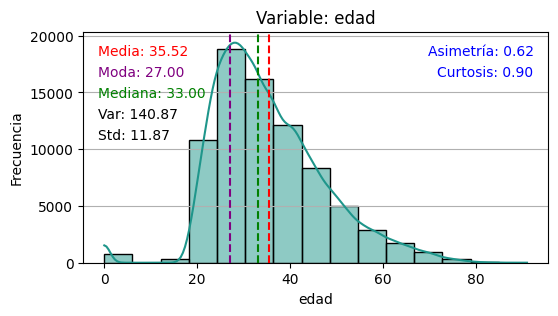

In [575]:
plot_histograma(data=X_train, column=const_edad, snk=True)

Como se observa en el gráfico anterior, la edad presenta `asimetría` (con un valor de $0.62$).

Debido a esto, se decide imputar l0s registros con edad igual a cero en la `edad` utilizando la `mediana`.

In [576]:
mediana_edad = (X_train[const_edad]).median()

In [577]:
X_train[const_edad] = (X_train[const_edad]).replace(0, mediana_edad)

In [578]:
X_test[const_edad] = (X_test[const_edad]).replace(0, mediana_edad)

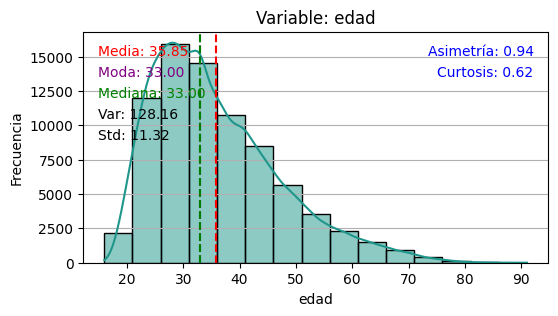

In [579]:
plot_histograma(data=X_train, column=const_edad, snk=True)

Como se observa en el gráfico anterior, al imputar por la *mediana* se altera la distribución de la variable `edad`.

#### Paso 2.3.2 - Imputación de variables categóricas mediante `mediana`

Comenzamos imputando las variables categóricas utilizando la `mediana`:

In [580]:
cols_a_imputar = [
    "establecimiento_descripcion",
    "nacionalidad_descripcion",
    "estado_civil_descripcion",
    "nivel_instruccion_descripcion",
    "ultima_situacion_laboral_descripcion",
    "capacitacion_laboral_al_ingresar_descripcion",
    "ultimo_lugar_residencia_descripcion",  
    "ultima_provincia_residencia_descripcion",
    "jurisdiccion_descripcion",
    "establecimiento_procedencia_descripcion",
    "delito1_descripcion",
    "horas_trabajo_remunerado_descripcion",
    "participacion_programa_educativo_descripcion",
    "participacion_actividades_deportivas",
    "recibio_atencion_medica_ult_anio_descripcion",
    "recibio_visitas_ultimo_anio",
    "participo_alteracion_orden_ult_anio_descripcion",
    "tipo_infraccion_disciplinaria_descripcion",
    "calificacion_conducta_descripcion",
    "tentativa_fugas_evasiones_descripcion",
    "fue_lesionado_descripcion",
    "reparticion_descripcion",
]

In [581]:
for col in cols_a_imputar:
    moda = (X_train[col]).mode()[0]

    X_train[col] = X_train[col].fillna(moda)
    X_test[col] = X_test[col].fillna(moda)

Finalmente, se borra la variable `sancion_aplicada_descripcion` de los dataset de *train* y *test*, ya que tiene una gran cantidad de nulos:

In [582]:
X_train.drop(columns=["sancion_aplicada_descripcion"], inplace=True)
X_test.drop(columns=["sancion_aplicada_descripcion"], inplace=True)

In [583]:
col_categoricas.remove("sancion_aplicada_descripcion")

## Paso 3 - Tratamiento de outliers

### Paso 3.1 - Análisis de outliers

Comenzamos haciendo un análisis de outliers sobre las variables numéricas:

#### Paso 3.1.1 - Análisis de `edad`

A continuación, se muestra un análisis de outliers para la variable `edad`, utilizando gráficos (histogramas + boxplot), como así también *IQR*.

Se encontraron un total de $1754$ outliers en *train* ($2.24$%) y $710$ outliers en *test* ($2.11$%).

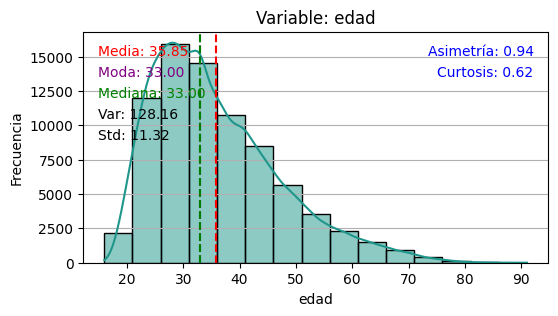

In [584]:
plot_histograma(X_train, const_edad, mvd= True, snk=True)

In [585]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, const_edad)

print(f"""Variable Edad
      Media:      {media:.2f}
      Moda:       {moda:.2f}
      Mediana:    {mediana:.2f}
      Mínimo:     {min:.2f}
      Máximo:     {max:.2f}
      Varianza:   {var:.2f}
      Desvío:     {std:.2f}
      Skewness:   {skewness:.2f}
      Kurtosis:   {kurtosis:.2f}
""")

Variable Edad
      Media:      35.85
      Moda:       33.00
      Mediana:    33.00
      Mínimo:     16.00
      Máximo:     91.00
      Varianza:   128.16
      Desvío:     11.32
      Skewness:   0.94
      Kurtosis:   0.62



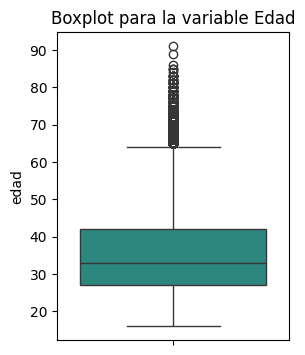

In [586]:
# Boxplot de la variable Edad
plt.figure(figsize=(3, 4))
sns.boxplot(data=X_train, y=const_edad, color=default_green_color)
plt.title("Boxplot para la variable Edad")
plt.show()

In [587]:
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, const_edad)

print(f"""Variable Edad
    Q1 (25%):   {Q1:.2f}
    Q2 (50%):   {Q2:.2f}
    Q3 (75%):   {Q3:.2f}
    IQR:        {IQR:.2f}
    Mín IQR:    {min_iqr:.2f}
    Max IQR:    {max_iqr:.2f}
""")

Variable Edad
    Q1 (25%):   27.00
    Q2 (50%):   33.00
    Q3 (75%):   42.00
    IQR:        15.00
    Mín IQR:    4.50
    Max IQR:    64.50



In [588]:
mask_edad_menor_min_iqr_train = X_train[const_edad] <= min_iqr
mask_edad_mayor_miax_iqr_train = X_train[const_edad] >= max_iqr

mask_edad_menor_min_iqr_test = X_test[const_edad] <= min_iqr
mask_edad_mayor_miax_iqr_test = X_test[const_edad] >= max_iqr

print(f"Cantidad de registros con edad menor al min_iqr ({min_iqr}) en \"Train\": {len(X_train[mask_edad_menor_min_iqr_train])}")
print(f"Cantidad de registros con edad menor al min_iqr ({min_iqr}) en \"Test\": {len(X_test[mask_edad_menor_min_iqr_test])}")

print(f"Cantidad de registros con edad mayor al max_iqr ({max_iqr}) en \"Train\": {len(X_train[mask_edad_mayor_miax_iqr_train])}")
print(f"Cantidad de registros con edad mayor al max_iqr ({max_iqr}) en \"Test\": {len(X_test[mask_edad_mayor_miax_iqr_test])}")

Cantidad de registros con edad menor al min_iqr (4.5) en "Train": 0
Cantidad de registros con edad menor al min_iqr (4.5) en "Test": 0
Cantidad de registros con edad mayor al max_iqr (64.5) en "Train": 1754
Cantidad de registros con edad mayor al max_iqr (64.5) en "Test": 710


#### Paso 3.1.2 - Análisis de `duracion_condena_anios`

A continuación, se muestra un análisis de outliers para la variable `duracion_condena_anios`, utilizando gráficos (histogramas + boxplot), como así también *IQR*.

Se encontraron un total de $2355$ outliers en *train* ($3$%) y $1039$ outliers en *test* ($3.01$%).

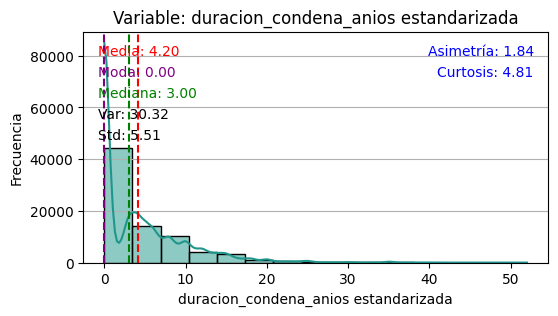

In [589]:
plot_histograma(X_train, "duracion_condena_anios", mvd= True, snk=True, xlabel="duracion_condena_anios estandarizada")

In [590]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, "duracion_condena_anios")

print(f"""Variable duracion_condena_anios
      Media:      {media:.2f}
      Moda:       {moda:.2f}
      Mediana:    {mediana:.2f}
      Mínimo:     {min:.2f}
      Máximo:     {max:.2f}
      Varianza:   {var:.2f}
      Desvío:     {std:.2f}
      Skewness:   {skewness:.2f}
      Kurtosis:   {kurtosis:.2f}
""")

Variable duracion_condena_anios
      Media:      4.20
      Moda:       0.00
      Mediana:    3.00
      Mínimo:     0.00
      Máximo:     52.00
      Varianza:   30.32
      Desvío:     5.51
      Skewness:   1.84
      Kurtosis:   4.81



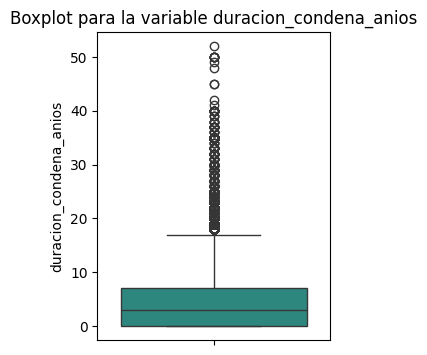

In [591]:
plt.figure(figsize=(3, 4))
sns.boxplot(data=X_train, y="duracion_condena_anios", color=default_green_color)
plt.title("Boxplot para la variable duracion_condena_anios")
plt.show()

In [592]:
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, "duracion_condena_anios")

print(f"""Variable duracion_condena_anios
    Q1 (25%):   {Q1:.2f}
    Q2 (50%):   {Q2:.2f}
    Q3 (75%):   {Q3:.2f}
    IQR:        {IQR:.2f}
    Mín IQR:    {min_iqr:.2f}
    Max IQR:    {max_iqr:.2f}
""")

Variable duracion_condena_anios
    Q1 (25%):   0.00
    Q2 (50%):   3.00
    Q3 (75%):   7.00
    IQR:        7.00
    Mín IQR:    -10.50
    Max IQR:    17.50



In [593]:
mask_menor_min_iqr_train = X_train["duracion_condena_anios"] <= min_iqr
mask_mayor_miax_iqr_train = X_train["duracion_condena_anios"] >= max_iqr

mask_menor_min_iqr_test = X_test["duracion_condena_anios"] <= min_iqr
mask_mayor_miax_iqr_test = X_test["duracion_condena_anios"] >= max_iqr

print(f"Cantidad de registros con duracion_condena_anios menor al min_iqr ({min_iqr}) en \"Train\": {len(X_train[mask_menor_min_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_anios menor al min_iqr ({min_iqr}) en \"Test\": {len(X_test[mask_menor_min_iqr_test])}")

print(f"Cantidad de registros con duracion_condena_anios mayor al max_iqr ({max_iqr}) en \"Train\": {len(X_train[mask_mayor_miax_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_anios mayor al max_iqr ({max_iqr}) en \"Test\": {len(X_test[mask_mayor_miax_iqr_test])}")

Cantidad de registros con duracion_condena_anios menor al min_iqr (-10.5) en "Train": 0
Cantidad de registros con duracion_condena_anios menor al min_iqr (-10.5) en "Test": 0
Cantidad de registros con duracion_condena_anios mayor al max_iqr (17.5) en "Train": 2355
Cantidad de registros con duracion_condena_anios mayor al max_iqr (17.5) en "Test": 1039


#### Paso 3.1.3 - Análisis de `duracion_condena_meses`

A continuación, se muestra un análisis de outliers para la variable `duracion_condena_meses`, utilizando gráficos (histogramas + boxplot), como así también *IQR*.

En este caso se encontró que la distribución tiene un valor muy alto de *Kurtosis* ($17.98$ en *train*), lo cual se debe a que presenta muchos outliers. Esto último puede observarse mejor en el *boxplot*.

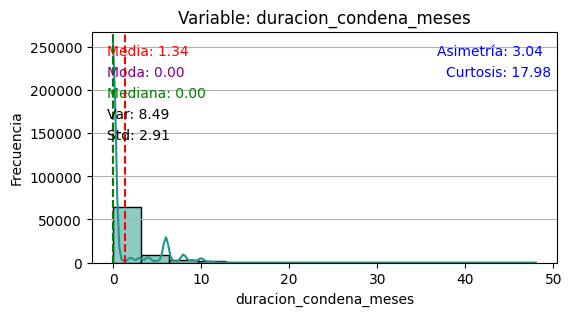

In [594]:
plot_histograma(X_train, "duracion_condena_meses", mvd= True, snk=True, xlabel="duracion_condena_meses")

In [595]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, "duracion_condena_meses")

print(f"""Variable duracion_condena_meses
      Media:      {media:.2f}
      Moda:       {moda:.2f}
      Mediana:    {mediana:.2f}
      Mínimo:     {min:.2f}
      Máximo:     {max:.2f}
      Varianza:   {var:.2f}
      Desvío:     {std:.2f}
      Skewness:   {skewness:.2f}
      Kurtosis:   {kurtosis:.2f}
""")

Variable duracion_condena_meses
      Media:      1.34
      Moda:       0.00
      Mediana:    0.00
      Mínimo:     0.00
      Máximo:     48.00
      Varianza:   8.49
      Desvío:     2.91
      Skewness:   3.04
      Kurtosis:   17.98



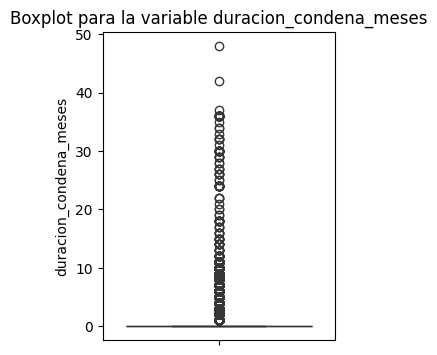

In [596]:
plt.figure(figsize=(3, 4))
sns.boxplot(data=X_train, y="duracion_condena_meses", color=default_green_color)
plt.title("Boxplot para la variable duracion_condena_meses")
plt.show()

In [597]:
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, "duracion_condena_meses")

print(f"""Variable duracion_condena_meses
    Q1 (25%):   {Q1:.2f}
    Q2 (50%):   {Q2:.2f}
    Q3 (75%):   {Q3:.2f}
    IQR:        {IQR:.2f}
    Mín IQR:    {min_iqr:.2f}
    Max IQR:    {max_iqr:.2f}
""")

Variable duracion_condena_meses
    Q1 (25%):   0.00
    Q2 (50%):   0.00
    Q3 (75%):   0.00
    IQR:        0.00
    Mín IQR:    0.00
    Max IQR:    0.00



In [598]:
mask_menor_min_iqr_train = X_train["duracion_condena_meses"] <= min_iqr
mask_mayor_miax_iqr_train = X_train["duracion_condena_meses"] >= max_iqr

mask_menor_min_iqr_test = X_test["duracion_condena_meses"] <= min_iqr
mask_mayor_miax_iqr_test = X_test["duracion_condena_meses"] >= max_iqr

print(f"Cantidad de registros con duracion_condena_meses menor al min_iqr ({min_iqr}) en \"Train\": {len(X_train[mask_menor_min_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_meses menor al min_iqr ({min_iqr}) en \"Test\": {len(X_test[mask_menor_min_iqr_test])}")

print(f"Cantidad de registros con duracion_condena_meses mayor al max_iqr ({max_iqr}) en \"Train\": {len(X_train[mask_mayor_miax_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_meses mayor al max_iqr ({max_iqr}) en \"Test\": {len(X_test[mask_mayor_miax_iqr_test])}")

Cantidad de registros con duracion_condena_meses menor al min_iqr (0.0) en "Train": 61101
Cantidad de registros con duracion_condena_meses menor al min_iqr (0.0) en "Test": 26273
Cantidad de registros con duracion_condena_meses mayor al max_iqr (0.0) en "Train": 78376
Cantidad de registros con duracion_condena_meses mayor al max_iqr (0.0) en "Test": 33591


#### Paso 3.1.4 - Definición estrategias para manejo de outliers

Este será el tratamiento de outliers que se hará en las siguientes variables:

- `edad`: se estudiará implementar una imputación por `media`, `mediana` y `moda` como así también transformaciones `logarítmicas` y por `raíz cuadrada`. Luego se analizarán sus distribuciones y se elegirá a la que mas se aproxime a una normal.
- `duracion_condena_anios`: se estudiará implementar una imputación por `media`, `mediana` y `moda` como así también transformaciones `logarítmicas` y por `raíz cuadrada`. Luego se analizarán sus distribuciones y se elegirá a la que mas se aproxime a una normal.
- `duracion_condena_meses`: debido a que tiene una gran cantidad de outliers, esta columna será eliminada.

### Paso 3.2 - tratamiento de outliers en variables numéricas

#### Paso 3.2.1 - tratamiento de outliers en variable `edad`

In [599]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, const_edad)
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, const_edad)

In [600]:
print(f"Media: {media}\nMediana: {mediana}\nModa: {moda}")

Media: 35.84953302031234
Mediana: 33.0
Moda: 33


In [601]:
# Dataset con imputación por media
X_train_edad_media = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
mask_outliers_edad_iqr = (X_train_edad_media[const_edad] < min_iqr) | (X_train_edad_media[const_edad] > max_iqr)

X_train_edad_media.loc[mask_outliers_edad_iqr, const_edad] = media

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1400\341752905.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '35.84953302031234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_edad_media.loc[mask_outliers_edad_iqr, const_edad] = media


In [602]:
# Dataset con imputación por mediana
X_train_edad_mediana = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
mask_outliers_edad_iqr = (X_train_edad_mediana[const_edad] < min_iqr) | (X_train_edad_mediana[const_edad] > max_iqr)

X_train_edad_mediana.loc[mask_outliers_edad_iqr, const_edad] = mediana

In [603]:
# Dataset con imputación por moda
X_train_edad_moda = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
mask_outliers_edad_iqr = (X_train_edad_moda[const_edad] < min_iqr) | (X_train_edad_moda[const_edad] > max_iqr)

X_train_edad_moda.loc[mask_outliers_edad_iqr, const_edad] = moda

In [604]:
# Dataset con transformación logarítmica
X_train_edad_logaritmica = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
X_train_edad_logaritmica[const_edad] = np.log1p(X_train_edad_logaritmica[const_edad])

In [605]:
# Dataset con transformación por raíz cuadrada
X_train_edad_sqrt = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
X_train_edad_sqrt[const_edad] = np.sqrt(X_train_edad_sqrt[const_edad])

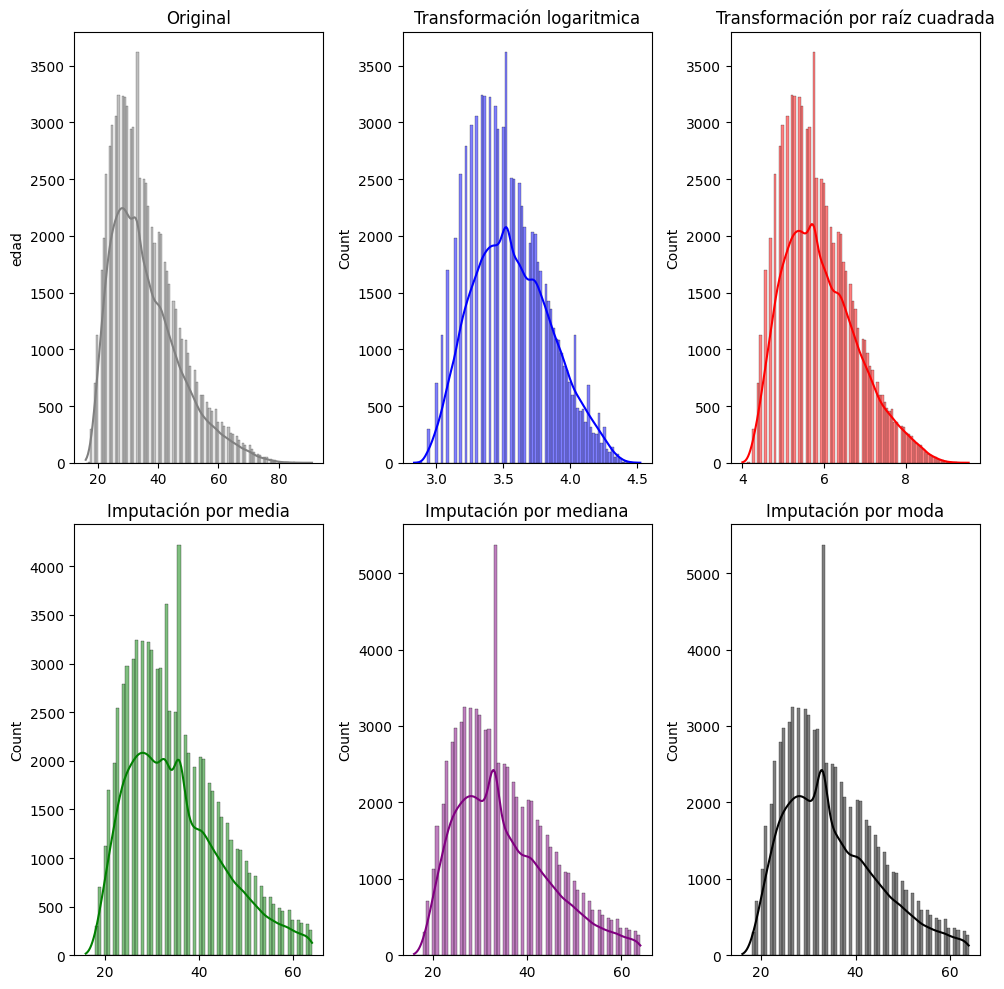

In [606]:
graficar_comparacion_tratamiento_outliers(X_train, X_train_edad_media, X_train_edad_mediana, X_train_edad_moda, X_train_edad_logaritmica, X_train_edad_sqrt, col=const_edad)

En los gráficos anteriores se puede observar que la `transformación logarítmica` es la que más se asemeja a una distribución normal, por lo cual la aplicaremos a la variable `edad` en *train* y *test*.

In [607]:
# Aplicamos transformación logarítmica a train y test por separado.
X_train[const_edad] = np.log1p(X_train[const_edad])
X_test[const_edad] = np.log1p(X_test[const_edad])

In [608]:
# se borran dataframes innecesarios
del X_train_edad_media, X_train_edad_mediana, X_train_edad_moda, X_train_edad_logaritmica, X_train_edad_sqrt

#### Paso 3.2.2 - tratamiento de outliers en variable `duracion_condena_anios`

In [609]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, "duracion_condena_anios")
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, "duracion_condena_anios")

In [610]:
print(f"Media: {media}\nMediana: {mediana}\nModa: {moda}")

Media: 4.1961187098091255
Mediana: 3.0
Moda: 0


In [611]:
# Dataset con imputación por media
X_train_media = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
mask_outliers_iqr = (X_train_media["duracion_condena_anios"] < min_iqr) | (X_train_media["duracion_condena_anios"] > max_iqr)

X_train_media.loc[mask_outliers_iqr, "duracion_condena_anios"] = media

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1400\4257049693.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.1961187098091255' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_media.loc[mask_outliers_iqr, "duracion_condena_anios"] = media


In [612]:
# Dataset con imputación por mediana
X_train_mediana = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
mask_outliers_iqr = (X_train_mediana["duracion_condena_anios"] < min_iqr) | (X_train_mediana["duracion_condena_anios"] > max_iqr)

X_train_mediana.loc[mask_outliers_iqr, "duracion_condena_anios"] = mediana

In [613]:
# Dataset con imputación por moda
X_train_moda = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
mask_outliers_iqr = (X_train_moda["duracion_condena_anios"] < min_iqr) | (X_train_moda["duracion_condena_anios"] > max_iqr)

X_train_moda.loc[mask_outliers_iqr, "duracion_condena_anios"] = moda

In [614]:
# Dataset con transformación logarítmica
X_train_logaritmica = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
X_train_logaritmica["duracion_condena_anios"] = np.log1p(X_train_logaritmica["duracion_condena_anios"])

In [615]:
# Dataset con transformación por raíz cuadrada
X_train_sqrt = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
X_train_sqrt["duracion_condena_anios"] = np.sqrt(X_train_sqrt["duracion_condena_anios"])

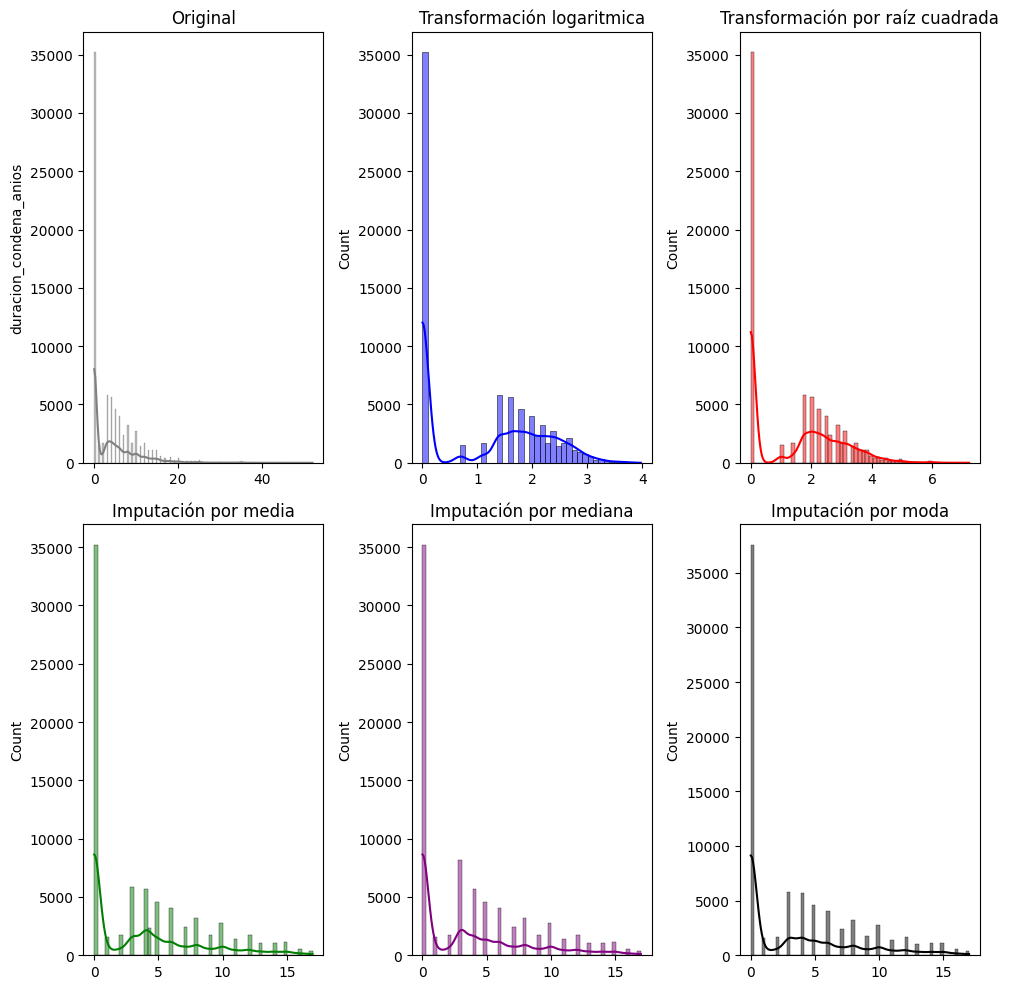

In [616]:
graficar_comparacion_tratamiento_outliers(X_train, X_train_media, X_train_mediana, X_train_moda, X_train_logaritmica, X_train_sqrt, col="duracion_condena_anios")

En los gráficos anteriores se puede observar que no hay una transformación que permita tener una distribución similar a la normal para la variable `duracion_condena_anios`.

Para determinar cual de estas transformaciones utilizaremos, nos basamos en la cantidad de outliers que tenga cada una luego de ser aplicada sobre *X_train*.

In [617]:
datasets = {
    "X_train": X_train,
    "Media": X_train_media,
    "Mediana": X_train_mediana,
    "Moda": X_train_moda,
    "Transformación logarítmica": X_train_logaritmica,
    "Transformación por raíz cuadrada": X_train_sqrt
}

total = len(X_train)

for key, value in datasets.items():
    ds = value
    Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(ds, "duracion_condena_anios")

    mask_outliers_iqr = (ds["duracion_condena_anios"] < min_iqr) | (ds["duracion_condena_anios"] > max_iqr)
    cant_outliers = len(ds[mask_outliers_iqr])

    print(f"""=================================================================
          Dataset:                          {key}
          Cantidad de outliers en Train:    {cant_outliers}
          Porcentaje de outliers en Train:  {np.round(cant_outliers*100/total,2)}
          """)


          Dataset:                          X_train
          Cantidad de outliers en Train:    2355
          Porcentaje de outliers en Train:  3.0
          
          Dataset:                          Media
          Cantidad de outliers en Train:    950
          Porcentaje de outliers en Train:  1.21
          
          Dataset:                          Mediana
          Cantidad de outliers en Train:    950
          Porcentaje de outliers en Train:  1.21
          
          Dataset:                          Moda
          Cantidad de outliers en Train:    950
          Porcentaje de outliers en Train:  1.21
          
          Dataset:                          Transformación logarítmica
          Cantidad de outliers en Train:    0
          Porcentaje de outliers en Train:  0.0
          
          Dataset:                          Transformación por raíz cuadrada
          Cantidad de outliers en Train:    11
          Porcentaje de outliers en Train:  0.01
          


Como puede observarse en los resultados anteriores, la `transformación logarítmica` no tiene outliers en `X_train`, así que la aplicaremos tanto en *train* como *test*.

In [618]:
# Aplicamos transformación logarítmica a train y test por separado.
X_train["duracion_condena_anios"] = np.log1p(X_train["duracion_condena_anios"])
X_test["duracion_condena_anios"] = np.log1p(X_test["duracion_condena_anios"])

In [619]:
# se borran dataframes innecesarios
del X_train_media, X_train_mediana, X_train_moda, X_train_logaritmica, X_train_sqrt

#### Paso 3.2.3 - tratamiento de outliers en variable `duracion_condena_meses`

Como se mencionó en pasos anteriores, esta variable será eliminada tanto en *train* como *test* ya que tiene una gran cantidad de outliers.

In [620]:
X_train = X_train.drop(columns=["duracion_condena_meses"])
X_test = X_test.drop(columns=["duracion_condena_meses"])

In [621]:
col_numericas.remove("duracion_condena_meses")

### Paso 3.3 - conclusiones sobre el tratamiento de outliers

Estos son los resultados del análisis y tratamiento de outliers para las siguientes variables numéricas del dataset:

1. `edad`
    1. Se encontraron un total de $1754$ outliers en *train* ($2.24$%) y $710$ outliers en *test* ($2.11$%).
    1. Se exploraron las imputaciones por media, mediana y moda, como así también las transformaciones logarítmicas y por raíz cuadrada.
    1. Se aplicó una transformación logarítmica tanto en *train* como *test*, ya que esta transformación es la que genera una distribución más parecida a una *normal*.
1. `duracion_condena_anios`
    1. Se encontraron un total de $2355$ outliers en *train* ($3$%) y $1039$ outliers en *test* ($3.01$%).
    1. Se exploraron las imputaciones por media, mediana y moda, como así también las transformaciones logarítmicas y por raíz cuadrada.
    1. Como ninguna de estas transformaciones generó una distribución similar a una *normal*, se analizaron la cantidad de *nuevos outliers* al aplicarlas sobre *train*.
    1. Se aplicó una transformación logarítmica tanto en *train* como *test*, ya que luego de aplicarla sobre *train* no hubo más outliers.
1. `duracion_condena_meses`
    1. Se encontró que la distribución tiene un valor muy alto de *Kurtosis* ($17.98$ en *train*), lo cual se debe a que presenta muchos outliers.
    1. Se elimina la variable tanto en *train* como en *test*.

## Paso 4 - Creación de nuevas features

## Paso 5 - Discretización

## Paso 6 - Codificación

### Paso 6.1 - Codificación de variable target

Codificaremos la variable target `tuvo_reduccion_pena_descripcion` mediante label encoding.

Para ello, implementamos un [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de la biblioteca *sklearn*.

1. Primero, hay que ajustar y transformar este *encoder* sobre los datos de *train*.
1. Una vez ajustado, podremos aplicar el mismo *encoder* sobre los datos de *test*.

In [622]:
# Creamos el encoder y hacemos fit_transform en train
labelEncoder = LabelEncoder()
y_train = labelEncoder.fit_transform(y_train)

In [623]:
# Una vez creado y ajustado el encoder, podemos aplicar la misma técnica en test
y_test = labelEncoder.transform(y_test)

### Paso 6.2 - Codificación de variable booleanas

Estas son las variables *booleanas* presentes en los datasets de *train* y *test*, con sus respectivos valores.

1. `participacion_actividades_deportivas`
    1. Los valores actuales son `1.` y `0.` (`Si` y `No`, respectivamente).
1. `recibio_visitas_ultimo_anio`
    1. Los valores actuales son `1.` y `0.` (`Si` y `No`, respectivamente).
1. `tentativa_suicidio`
    1. Esta variable cuenta con tres valores posibles: `0`, `1` y `2`.
    1. *NOTA*: técnicamente NO es booleana, ya que posee 3 valores posibles.
1. `participa_programa_pre_libertad`
    1. Esta variable posee los valores `1.`, `0.` (`Si` y `No`, respectivamente) y `Sin condena` (ver imputación de nulos en paso `2.2.1`).

Se opta por codificar solamente a la variable `participa_programa_pre_libertad`, ya que las otras ya poseen *cierta* codificación.

Estos son los pasos que se realizarán para codificar la variable `participa_programa_pre_libertad`:

1. Transformaremos los valores `Si` y `No`, según tengan los valores `1` y `0`.
    1. En cuanto al valor `Sin condena`, quedará tal cual se imputó.
1. Se explorarán las siguientes técnicas de codificación:
    1. `One-Hot encoding` y `Frequency encoding`.
1. Se analizarán las técnicas aplicadas y se decidirá si es conveniente aplicar (o no) solamente una de ellas sobre *train* y *test*, justificando el por qué.

#### Paso 6.2.1 - Codificación de variable `participa_programa_pre_libertad`

In [624]:
## lambda function que devuelve "Si" para los casos en que el valor es 1., sino devuelve "No"
si_no_encoder = lambda x: "Si" if x == "1.0" else ("No" if x == "0.0" else x)

Comenzamos transformando los valores con `1.` y `0.` en `Si` y `No`, respectivamente.

In [625]:
X_train["participa_programa_pre_libertad"] = X_train["participa_programa_pre_libertad"].apply(si_no_encoder)
X_test["participa_programa_pre_libertad"] = X_test["participa_programa_pre_libertad"].apply(si_no_encoder)

A continuación se muestra el resultado de aplicar `One-Hot encoding`.

Como se puede observar, se generan tres columnas nuevas, acorde a la cardinalidad de la variable `participa_programa_pre_libertad`.

In [626]:
ohe = OneHotEncoder(sparse_output=False)

encoded_array = ohe.fit_transform(X_train[["participa_programa_pre_libertad"]])
columns=ohe.get_feature_names_out(["participa_programa_pre_libertad"])
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(["participa_programa_pre_libertad"]))
encoded_df.head(5)

,participa_programa_pre_libertad_No,participa_programa_pre_libertad_Si,participa_programa_pre_libertad_Sin condena
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


En las siguientes celdas se puede observar el resultado de aplicar `Frequency encoding`:

In [627]:
X_train["participa_programa_pre_libertad"].value_counts(normalize=True)

participa_programa_pre_libertad
No             0.530252
Sin condena    0.398272
Si             0.071476
Name: proportion, dtype: float64

In [628]:
freq_encoding = X_train["participa_programa_pre_libertad"].value_counts(normalize=True)
X_train["participa_programa_pre_libertad"].map(freq_encoding)

43529     0.398272
86397     0.530252
106422    0.071476
74632     0.530252
12782     0.530252
            ...   
61705     0.398272
80080     0.398272
41447     0.530252
80206     0.530252
19650     0.530252
Name: participa_programa_pre_libertad, Length: 78376, dtype: float64

En base a las pruebas realizadas, podemos sacar las siguientes conclusiones sobre las dos técnicas de encoding aplicadas sobre la variable `participa_programa_pre_libertad` en *X_train*:

- `One-hot encoding`:
    - Esta técnica genera tres columnas nuevas, acorde a la cardinalidad de la variable.
    - *NO* resulta conveniente aplicarla, ya que aumenta la dimensionalidad del dataset (reemplazaríamos una columna por tres).
- `Frequency encoding`:
    - Tenemos dos categorías frecuentes: `No` ($53$%) y `Sin condena` ($39.8$%).
    - La tercer categoría es poco frecuente: `Si` ($7.1$%).
    - Cuando esto sucede (presencia de categorías infrecuentes) se recomienda agruparlas, pero en nuestro caso no sería conveniente, ya que podría perderse la importancia de este valor al combinarlo con `Sin condena` o `No` (este último, incluso, carecería de sentido agruparlo con `Si`).

Por los motivos mencionados anteriormente, se decide ***NO*** aplicar encoding en la variable `participa_programa_pre_libertad`.

### Paso 6.3 - Codificación de variable categóricas

En esta sección, se explorarán tres técnicas de encoding sobre las variable categóricas del dataset:

- `Ordinal encoding`: se analizará en los casos de variables que tengan un orden lógico.
- `Frequency encoding`: se analizará en los casos de variables en donde su frecuencia tenga una fuerte relación sobre la variable target (`tuvo_reduccion_pena_descripcion`).
- `Target encoding`: se analizará en los casos de variables que tengan alta cardinalidad.

Las siguientes técnicas ***NO*** serán exploradas sobre las variable categóricas del dataset:

- `One-hot encoding`: ya que no se desea aumentar la dimensionalidad del dataset.
- `Hashing encoding`: ya que no hay casos con cardinalidad extrema.
- `Cyclic encoding`: ya que no hay variables con patrones cíclicos en el dataset.

#### Paso 6.3.1 - Ordinal encoding

Estas son las columnas y sus respectivas categorías sobre las cuales se explorará el método de `ordinal encoding`:

1. `nivel_instruccion_descripcion`
    1. `Ninguno`
    1. `Primario incompleto`
    1. `Primario completo`
    1. `Secundario incompleto`
    1. `Secundario completo`
    1. `Terciario incompleto`
    1. `Universitario incompleto`
    1. `Terciario completo`
    1. `Universitario completo`
1. `tipo_infraccion_disciplinaria_descripcion`
    1. `No cometió Infracción disciplinaria`
    1. `Faltas leves`
    1. `Faltas media`
    1. `Faltas graves`

##### Paso 6.3.1.1 - Ordinal encoding en `nivel_instruccion_descripcion`

In [629]:
ordinal_encoder_nivel_instruccion = OrdinalEncoder(categories=[[
    "Ninguno",
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Terciario incompleto",
    "Universitario incompleto",
    "Terciario completo",
    "Universitario completo"
]])

In [630]:
X_train["nivel_instruccion_descripcion"] = ordinal_encoder_nivel_instruccion.fit_transform(X_train[["nivel_instruccion_descripcion"]]).astype(int)

In [631]:
X_test["nivel_instruccion_descripcion"] = ordinal_encoder_nivel_instruccion.transform(X_test[["nivel_instruccion_descripcion"]]).astype(int)

In [632]:
# Se borra el encoder, para liberar memoria
del ordinal_encoder_nivel_instruccion

##### Paso 6.3.1.2 - Ordinal encoding en `tipo_infraccion_disciplinaria_descripcion`

In [633]:
ordinal_encoder_tipo_infraccion = OrdinalEncoder(categories=[[
    "No cometió Infracción disciplinaria",
    "Faltas leves",
    "Faltas media",
    "Faltas graves"
]])

In [634]:
X_train["tipo_infraccion_disciplinaria_descripcion"] = ordinal_encoder_tipo_infraccion.fit_transform(X_train[["tipo_infraccion_disciplinaria_descripcion"]]).astype(int)

In [635]:
X_test["tipo_infraccion_disciplinaria_descripcion"] = ordinal_encoder_tipo_infraccion.transform(X_test[["tipo_infraccion_disciplinaria_descripcion"]]).astype(int)

In [636]:
# Se borra el encoder, para liberar memoria
del ordinal_encoder_tipo_infraccion

#### Paso 6.3.2 - Frequency encoding

En este caso, se analizará la técnica de `frequency encoding` sobre la variable `situacion_legal_descripcion`, ya que la misma tiene una relación fuerte con la variable target (si es distinta a `Condenado/a`, el target tendrá el valor `Sin condena`).

In [637]:
freq_situacion_legal = X_train["situacion_legal_descripcion"].value_counts(normalize=True)
freq_situacion_legal

situacion_legal_descripcion
Condenado/a       0.601728
Procesado/a       0.387836
Otra situación    0.007834
Inimputable       0.002603
Name: proportion, dtype: float64

En la tabla anterior se observa que hay categorías poco frecuentes (`Otra situación` e `Inimputable`).

Para evitar que esto provoque overfitting, se opta por agruparlas junta a la categoría `Procesado/a` en la nuva categoría `Sin condena efectiva`.
- Más info: [Let's datasciende - frequency encoding](https://letsdatascience.com/frequency-encoding/), sección *IX. Cautions and Best Practices with Frequency Encoding*

In [638]:
situacion_legal_encoder = lambda x: "Sin condena efectiva" if x != "Condenado/a" else x

Al aplicar los cambios mencionados, obtenemos las siguientes frecuencias:

In [640]:
X_train["situacion_legal_descripcion"].apply(situacion_legal_encoder).value_counts(normalize=True)

situacion_legal_descripcion
Condenado/a             0.601728
Sin condena efectiva    0.398272
Name: proportion, dtype: float64

In [641]:
X_train["situacion_legal_descripcion"] = X_train["situacion_legal_descripcion"].apply(situacion_legal_encoder)
X_test["situacion_legal_descripcion"] = X_test["situacion_legal_descripcion"].apply(situacion_legal_encoder)

In [ ]:
# Volvemos a generar el map de frecuencias
freq_situacion_legal = X_train["situacion_legal_descripcion"].value_counts(normalize=True)

In [645]:
X_train["situacion_legal_descripcion"] = X_train["situacion_legal_descripcion"].map(freq_situacion_legal)

In [647]:
X_test["situacion_legal_descripcion"] = X_test["situacion_legal_descripcion"].map(freq_situacion_legal)

#### Paso 6.3.3 - Target encoding